In [1]:
# Import neccessary packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

sns.set_theme(rc={'figure.figsize':(11.7,8.27)}) # Set a default theme for all charts 

In [2]:
df = pd.read_csv('student-scores.csv') # Load Dataset
df.head() # Inspect the first few rows

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [3]:
df.info() # Inspect the columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

In [4]:
df.nunique() # Ensure each record is unique by the id

id                            2000
first_name                     453
last_name                      707
email                         2000
gender                           2
part_time_job                    2
absence_days                    11
extracurricular_activities       2
weekly_self_study_hours         50
career_aspiration               17
math_score                      61
history_score                   51
physics_score                   50
chemistry_score                 51
biology_score                   68
english_score                   50
geography_score                 41
dtype: int64

In [5]:
df['avg_score'] = df[[ # Calculate a column for the average score of each student
    'math_score','history_score','physics_score','chemistry_score','biology_score','english_score','geography_score'
    ]].mean(axis=1)

df.info() # Inspect columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          2000 non-null   int64  
 1   first_name                  2000 non-null   object 
 2   last_name                   2000 non-null   object 
 3   email                       2000 non-null   object 
 4   gender                      2000 non-null   object 
 5   part_time_job               2000 non-null   bool   
 6   absence_days                2000 non-null   int64  
 7   extracurricular_activities  2000 non-null   bool   
 8   weekly_self_study_hours     2000 non-null   int64  
 9   career_aspiration           2000 non-null   object 
 10  math_score                  2000 non-null   int64  
 11  history_score               2000 non-null   int64  
 12  physics_score               2000 non-null   int64  
 13  chemistry_score             2000 

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'absence_days'}>,
        <Axes: title={'center': 'weekly_self_study_hours'}>],
       [<Axes: title={'center': 'math_score'}>,
        <Axes: title={'center': 'history_score'}>,
        <Axes: title={'center': 'physics_score'}>],
       [<Axes: title={'center': 'chemistry_score'}>,
        <Axes: title={'center': 'biology_score'}>,
        <Axes: title={'center': 'english_score'}>],
       [<Axes: title={'center': 'geography_score'}>,
        <Axes: title={'center': 'avg_score'}>, <Axes: >]], dtype=object)

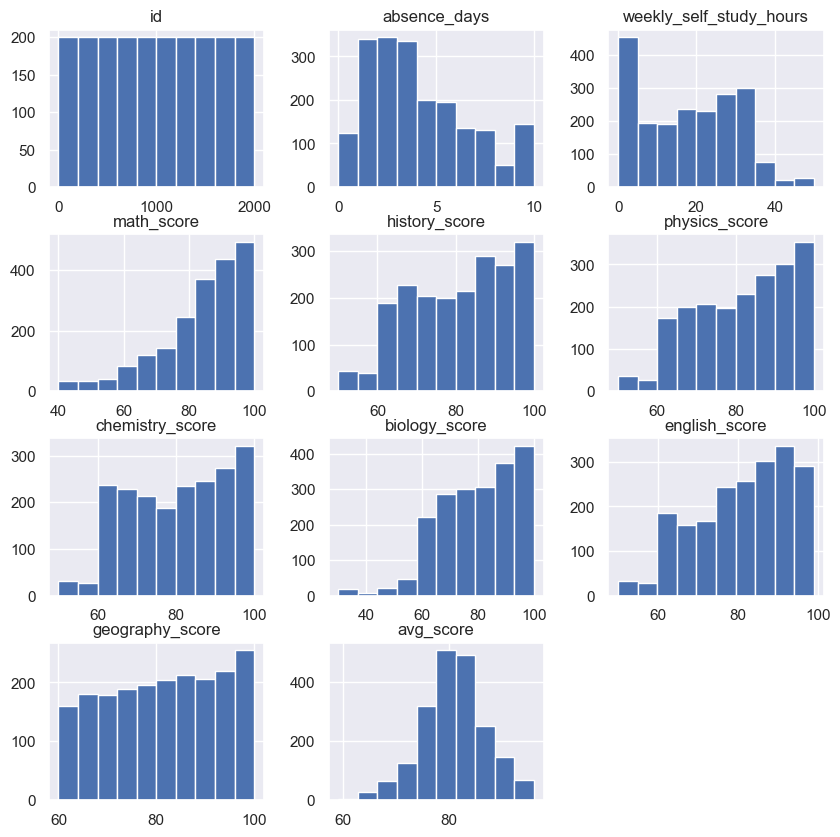

In [6]:
df.hist(figsize=(10,10)) #Visualise numerical columns (Absent days, Study hours and Test Scores) for their distribution

Text(0.5, 1.0, 'Correlation HeatMap')

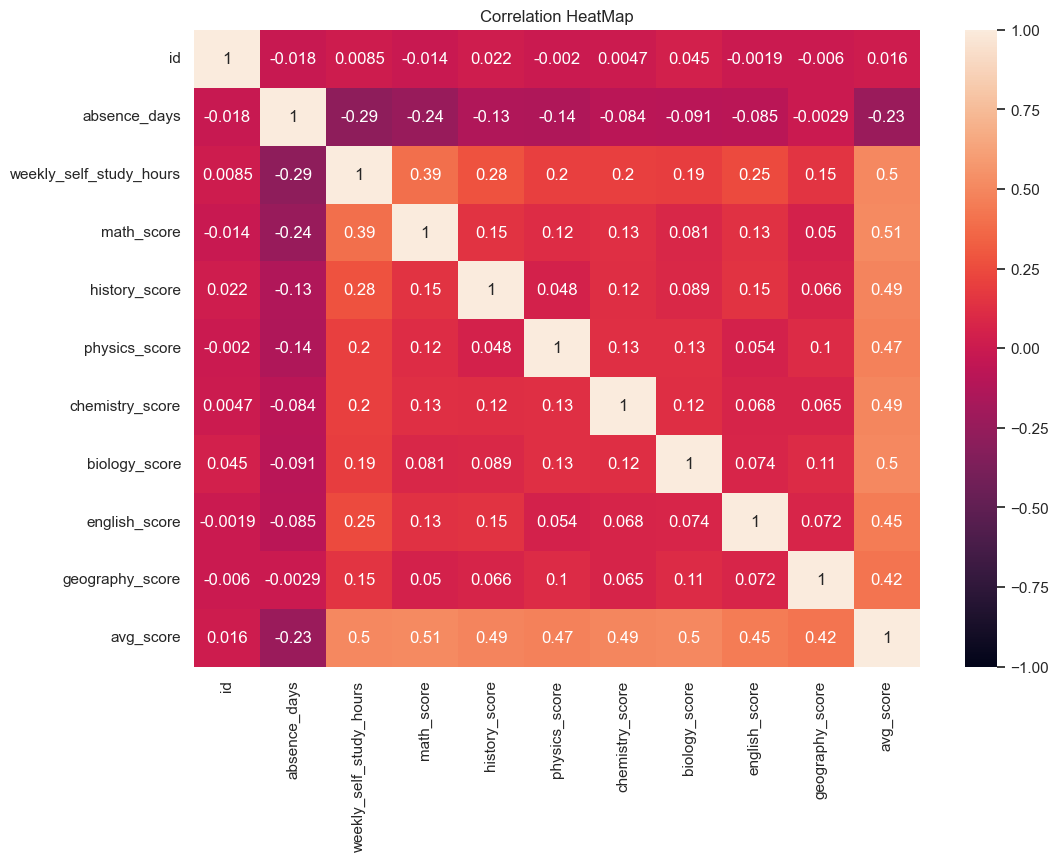

In [7]:
sns.heatmap(df.select_dtypes('number').corr(),vmin=-1, vmax=1,annot=True) # Visualise a correlation heatmap of the numerical columns

plt.title('Correlation HeatMap')

From the chart above we see that there are quite a few relationships in this dataset that are worth exploring
1. Weekly Self Study Hours has a weak positive correlation with most subject test scores indicated by Pearson Correlation coefficients between **0.2** and **0.5**. The exceptions to this are Biology and Geography with coefficients of **0.19** and **0.15** respectively, indicating no significant correlation.
2. However, Weekly Self Study Hours has a strong positive correlation with the Average student scores indicated by a correlation coefficient of **0.5**
3. Absence days has a weak negative correlation with Average score and Math Score, with coefficients of **-0.23** and **-0.24** respectively
4. Absence days has a weak negative correlation with Weekly Self Study Hours, with a coefficient of **-0.29** 
5. Mathematics is the strongest subject determinant of overall success with a coefficient of **0.51**
 
  
  
This means the direct relationships we will look into are
1. Weekly Self Study Hours → All Subject scores (looking closely at the Avergae Scores, *Biology* and *Geograpghy*)
2. Absence days → Average Student Score and Maths Score
3. Absence days → Weekly Self Study Hours 


# Weekly Self Study Hours → All Subject scores (looking closely at the Average Scores, *Biology* and *Geograpghy*)
To begin, visualize the relationship of all subjects with the Weekly Self Study Hours

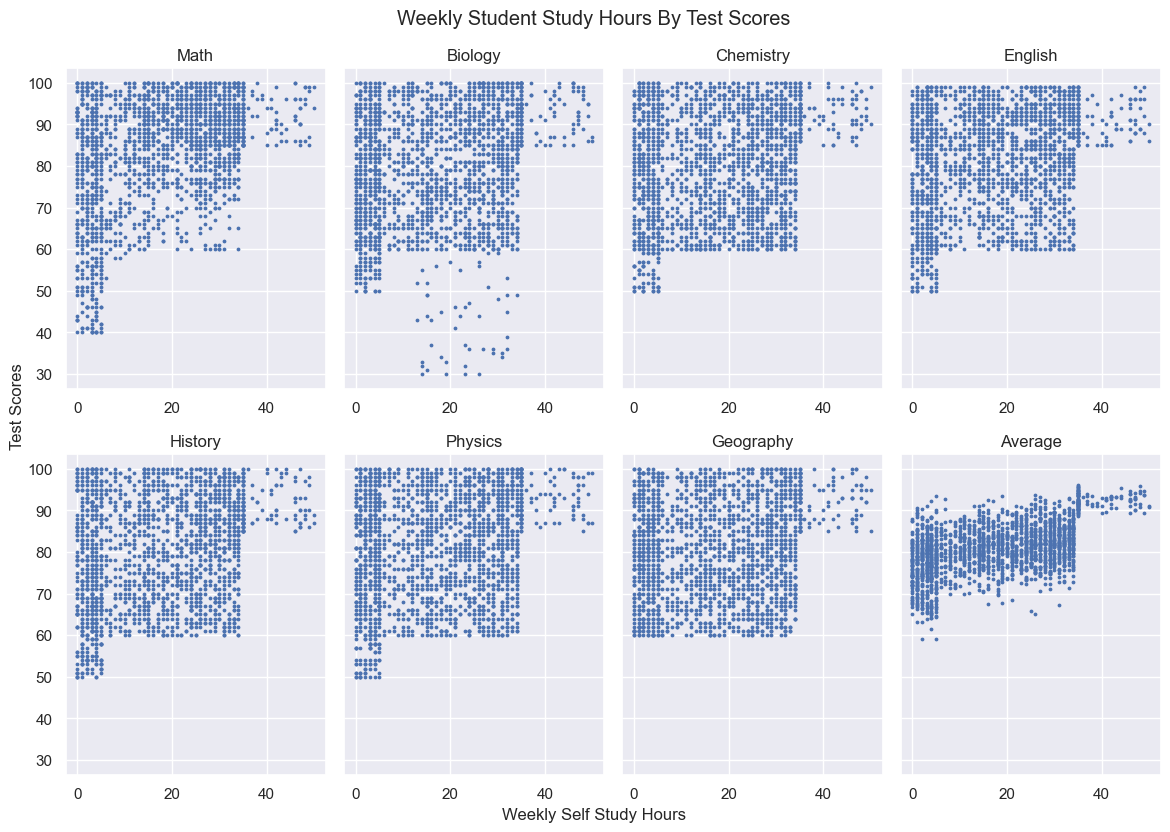

In [8]:
x = df['weekly_self_study_hours']


fig, axs = plt.subplots(2, 4,sharey=True) # Create multiple plots to display at once
fig.suptitle('Weekly Student Study Hours By Test Scores')
fig.text(0.5,0.001,'Weekly Self Study Hours',ha='center')
fig.text(0.001,0.5,'Test Scores',va='center',rotation='vertical')
axs[0, 0].scatter(x, df['math_score'],s=3)
axs[0, 0].set_title("Math")
axs[0, 1].scatter(x, df['biology_score'],s=3)
axs[0, 1].set_title("Biology")
axs[0, 2].scatter(x, df['chemistry_score'],s=3)
axs[0, 2].set_title("Chemistry")
axs[0, 3].scatter(x, df['english_score'],s=3)
axs[0, 3].set_title("English")
axs[1, 0].scatter(x, df['history_score'],s=3)
axs[1, 0].set_title("History")
axs[1, 1].scatter(x, df['physics_score'],s=3)
axs[1, 1].set_title("Physics")
axs[1, 2].scatter(x, df['geography_score'],s=3)
axs[1, 2].set_title("Geography")
axs[1, 3].scatter(x, df['avg_score'],s=3)
axs[1, 3].set_title("Average")
fig.tight_layout()

On visual analysis, we can see the correlations between the scores and the study hours hold true with the average score having the strongest correlation. 

On looking at *Geography*, it seems to be an easy subject to pass as the lowest score is 60, implying it simply doesn't need much studying 

On looking at *Biology*, we notice there are students who study between 10 and 35 hours weekly and still find it difficult to make scores more than 60, putting them at outlier positions within that subject. Let's have a closer look into this population

Text(0.5, 1.0, 'Do they take part in extracurriculars')

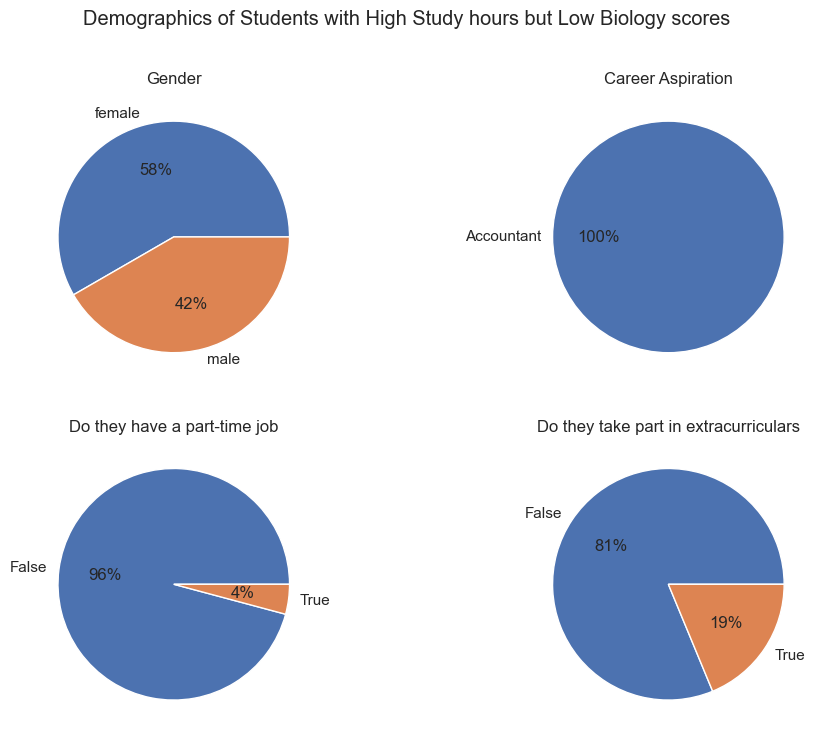

In [9]:
strange_bio = df.loc[(df['weekly_self_study_hours']>10) & (df['biology_score']<60)] # Filter students that study over 10 hours a week but score less than 60 in biology

# Filter demographic data on this population
strange_bio_sex = strange_bio.groupby('gender')['id'].count() # Find the gender demographics
strange_bio_career = strange_bio.groupby('career_aspiration')['id'].count() # Find the career aspiration demographics
strange_bio_job = strange_bio.groupby('part_time_job')['id'].count() # Find the part time job demographics
strange_bio_activities = strange_bio.groupby('extracurricular_activities')['id'].count() # Find the extracurricular demographics

fig, axs = plt.subplots(2,2)
fig.suptitle('Demographics of Students with High Study hours but Low Biology scores')
axs[0,0].pie(strange_bio_sex,labels=strange_bio_sex.index, autopct='%1.0f%%')
axs[0,0].set_title("Gender")
axs[0,1].pie(strange_bio_career,labels=strange_bio_career.index, autopct='%1.0f%%')
axs[0,1].set_title("Career Aspiration")
axs[1,0].pie(strange_bio_job,labels=strange_bio_job.index, autopct='%1.0f%%')
axs[1,0].set_title("Do they have a part-time job")
axs[1,1].pie(strange_bio_activities,labels=strange_bio_activities.index, autopct='%1.0f%%')
axs[1,1].set_title("Do they take part in extracurriculars")

We notice that this is more common in female students buy only slightly. Most of these students do not have a part-time job nor partake in extracurriculars so it is not an issue of time management. 
 
 Something interesting to note is that all these students wish to be accountants in future. The possible causes for this may be:
 - Study times are more focused towards business and calculation related subjects
 - These students simply do not have an affinity for the sciences, hence they already decided to be accountants
 - If these students belong to a specific classroom, homeroom or they all have the same biology teacher the fault may arise from there 
  
  More analysis needs to be performed to corroborate or disprove these theories

# Absence days → Average Student Score and Maths Score
First we shall visualise the spread of average scores in relation to the absence days

Text(0, 0.5, 'Average Scores of Students')

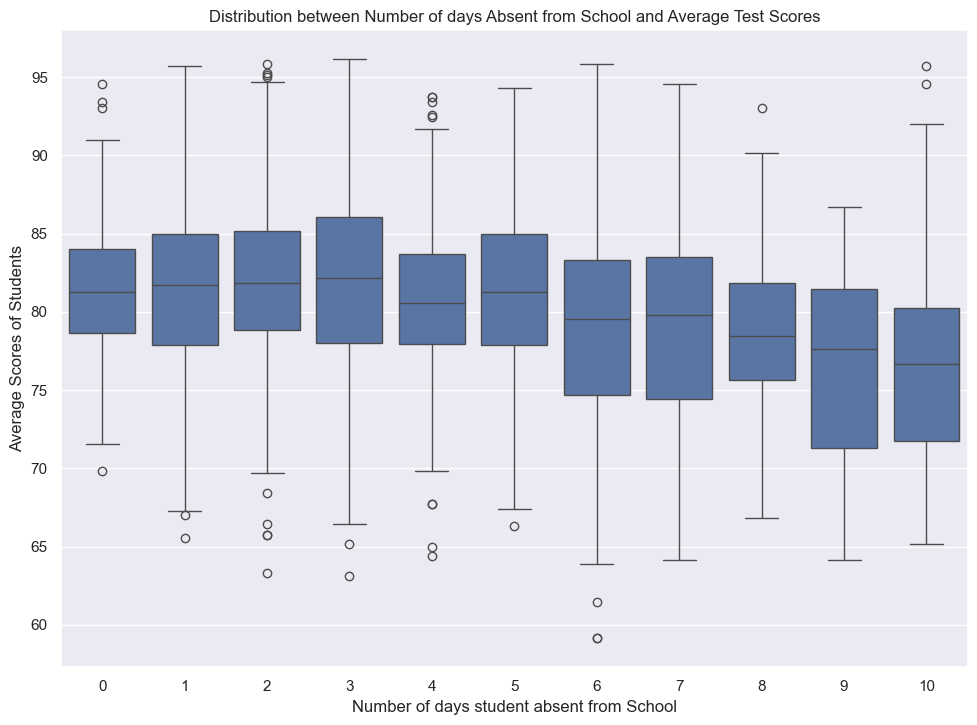

In [10]:
sns.boxplot(data=df,x='absence_days',y='avg_score') # Use a boxplot to show the spread of average scores against number of absent days
plt.title('Distribution between Number of days Absent from School and Average Test Scores')
plt.xlabel('Number of days student absent from School')
plt.ylabel('Average Scores of Students')

The medians in the boxplot above corroborate the negative correlation between number of absent days and Average Score. The more days of school a student misses, the more likely they are to get lower scores. Let us now explore the Math Scores specifically.

Text(0, 0.5, 'Math Scores of Students')

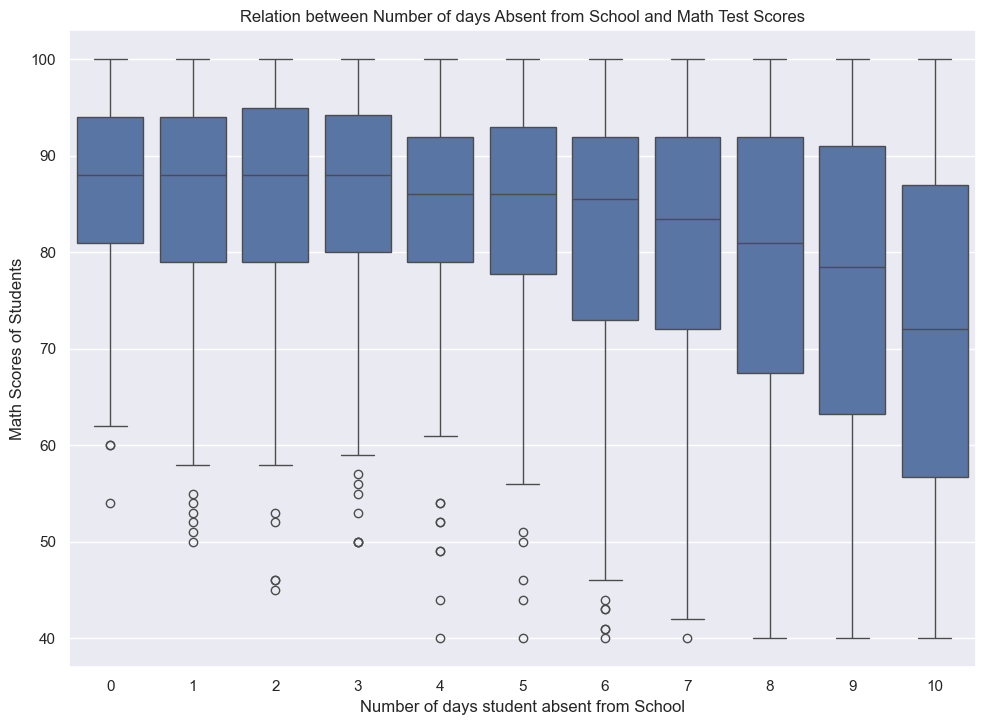

In [11]:
sns.boxplot(data=df,x='absence_days',y='math_score') # Use a boxplot to show the spread of math scores against number of absent days
plt.title('Relation between Number of days Absent from School and Math Test Scores')
plt.xlabel('Number of days student absent from School')
plt.ylabel('Math Scores of Students')

The chart above shows that math scores are very negatively dependent on the number of absent days. This could imply
- Students are intentionally being absent on Math class days which are affecting their score from either not liking the subject or not liking the teacher
- Math classes hold on most days and each Math class is so valuable the the more you are absent from them, the more likely you are to get a lower score 
 
  
For certain we have determined that Math scores have the largest influence on the Average Score.

# Absence days → Weekly Self Study Hours

We shall look at the distribution and density of absent days to weekly study hours

Text(0, 0.5, 'Weekly Self Study Hours')

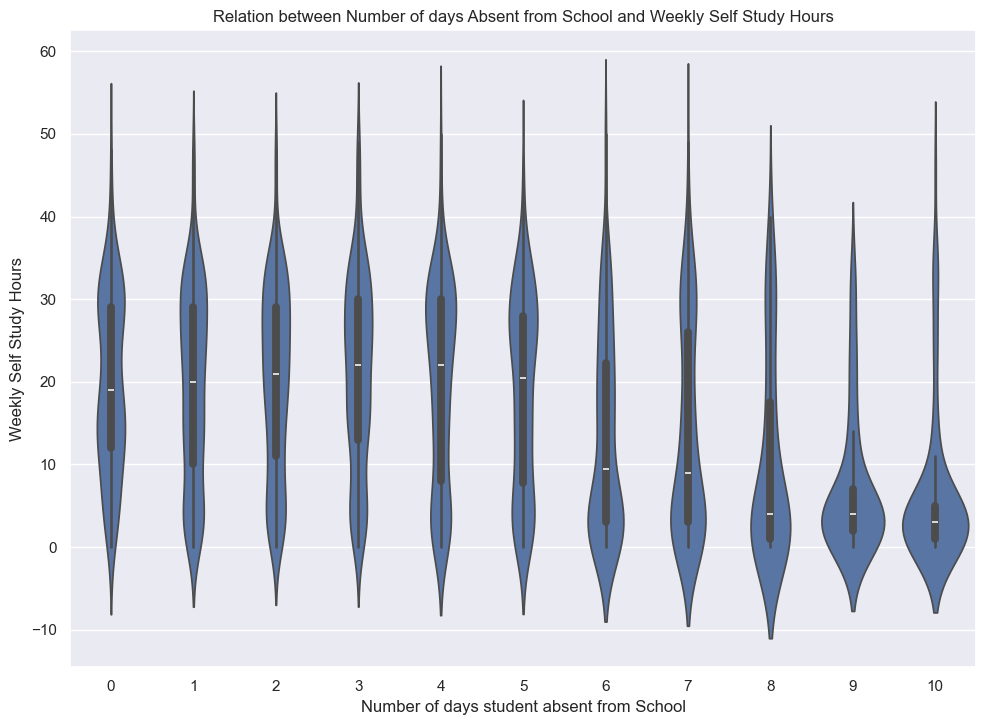

In [12]:
sns.violinplot(data=df, y='weekly_self_study_hours',x='absence_days') # Visualize the distibution and density
plt.title('Relation between Number of days Absent from School and Weekly Self Study Hours')
plt.xlabel('Number of days student absent from School')
plt.ylabel('Weekly Self Study Hours')

Not only do the medians of self study hours fall with the increase in number of days absent for a student, but the density of the population of students increases as well. This implies the more days of school a student misses, the less likey they are to study on their own. 
  
  As we have already established the relationship between average score and these two metrics, it seems poorly performing students are such from a lack of seriousness, being unwilling to attend classes or study on their own. 
   
   Now let us look at categorical metrics

In [13]:
df.select_dtypes(exclude=['number']).head()

,first_name,last_name,email,gender,part_time_job,extracurricular_activities,career_aspiration
0,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,False,Lawyer
1,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,False,Doctor
2,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,True,Government Officer
3,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,False,Artist
4,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,False,Unknown


On inspection, scores may be influenced by the time management ability of students affecting their weekly study hours which maybe closely related to having part-time jobs and participating in extra-curriculars. Let us check these metrics

Text(0, 0.5, 'Weekly Self Study Hours')

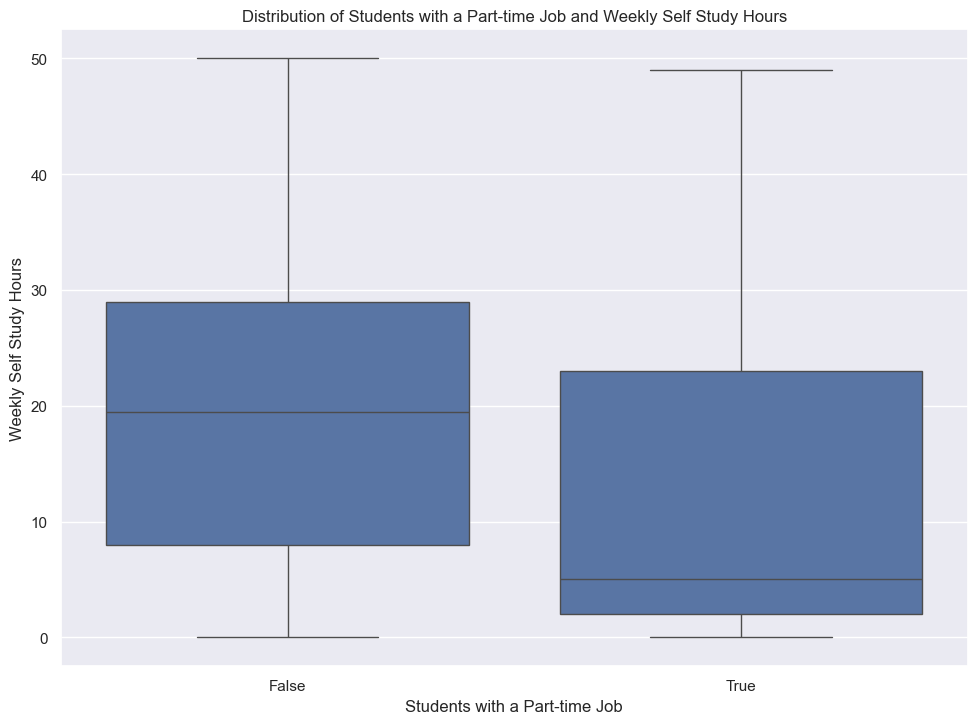

In [14]:
sns.boxplot(data=df,x='part_time_job',y='weekly_self_study_hours')
plt.title('Distribution of Students with a Part-time Job and Weekly Self Study Hours')
plt.xlabel('Students with a Part-time Job')
plt.ylabel('Weekly Self Study Hours')

Text(0, 0.5, 'Weekly Self Study Hours')

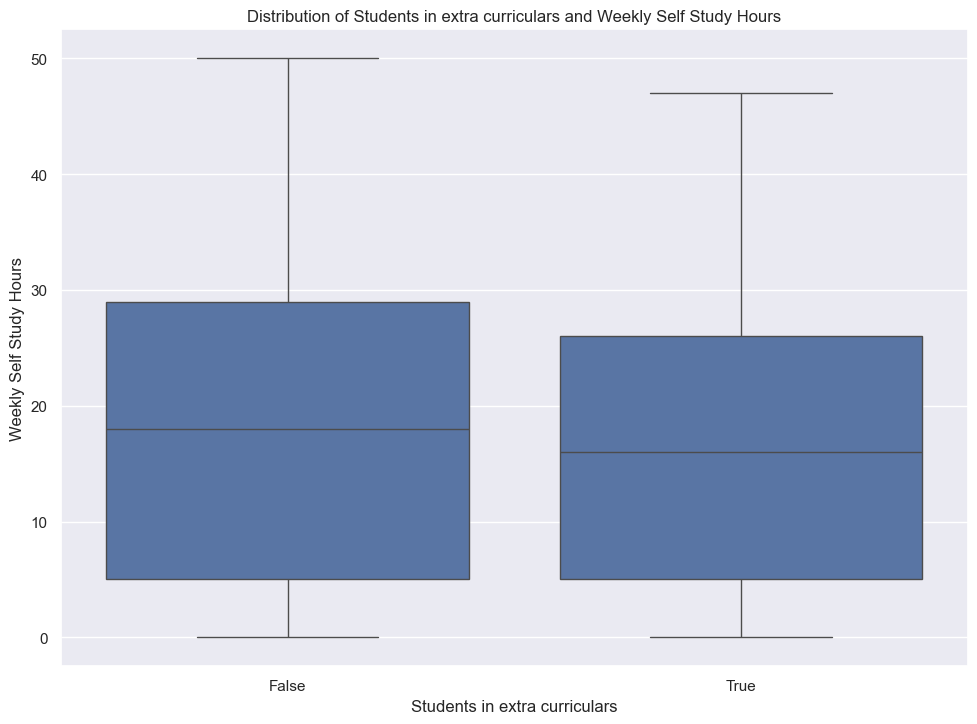

In [15]:
sns.boxplot(data=df,x='extracurricular_activities',y='weekly_self_study_hours')
plt.title('Distribution of Students in extra curriculars and Weekly Self Study Hours')
plt.xlabel('Students in extra curriculars')
plt.ylabel('Weekly Self Study Hours')

The effect of extra curriculars on study hours is minimal, however, the effect of having a part-time job greatly reduces amount of hours students study weekly. Let us see how it affects their scores in all subjects and the average 

In [16]:
subjects = [] # Empty list of subjects

# A for loop to get the list of the subjects and the average
for subject in df.columns: # Checks the names of all columns
    if subject.endswith('score'): # Checks if column name ends with the string 'score'
        subjects.append(subject) # Adds the name of any column that ends with the string 'score' to the list

print(subjects) # Inspect the list

['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score', 'avg_score']


Text(0, 0.5, 'Scores')

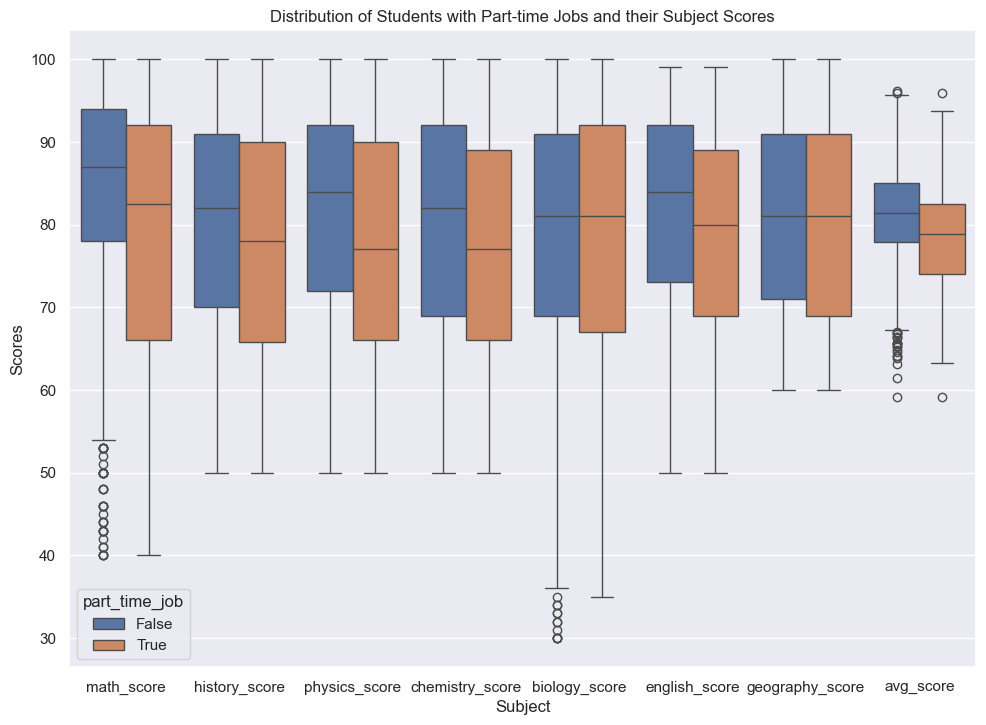

In [17]:
job = pd.melt( # Create a new data frame that holds each subject and score for each record
    pd.concat([df['part_time_job'],df[subjects]],axis=1), # Concatenate the subjects and the part-time job
    id_vars='part_time_job', # Use the part-time job as a key
    var_name="Subject", # Call the subject
    value_name="Score" # Call the score
)
sns.boxplot(data=job,x='Subject',y='Score',hue='part_time_job')
plt.title('Distribution of Students with Part-time Jobs and their Subject Scores')
plt.xlabel('Subject')
plt.ylabel('Scores')

Students with part-time jobs perform worse in all subjects except biology and geography(although they still have a lower 1st quartile). This corroborates that part-time jobs affects study times which in turn affects scores and our earlier theory that geography is an easy subject to pass and does not need intensive hours of study


# Career Aspiration Analysis
Let us look at the career aspirations of students and how they affect their scores and student life

Text(0, 0.5, 'Career Aspiration')

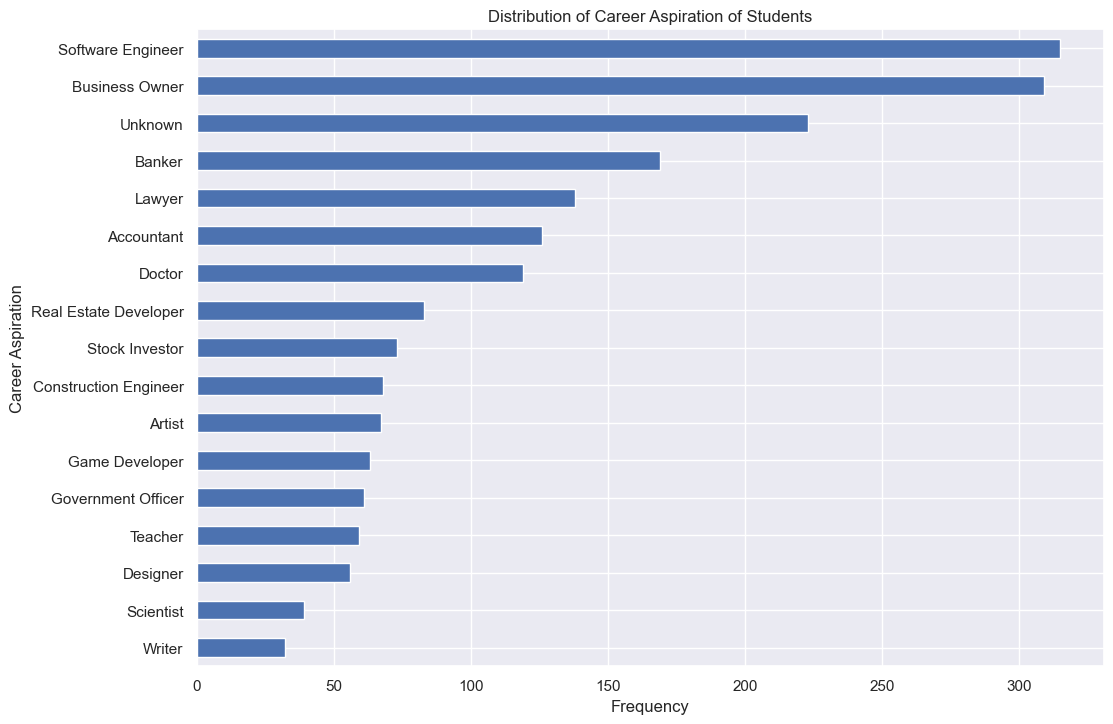

In [18]:
df['career_aspiration'].value_counts().sort_values().plot(kind='barh') # Visualise the distribution of different aspiration 
plt.title('Distribution of Career Aspiration of Students')
plt.xlabel('Frequency')
plt.ylabel('Career Aspiration')

Visualize the average scores of each career aspiration

Text(0, 0.5, 'Career Aspiration')

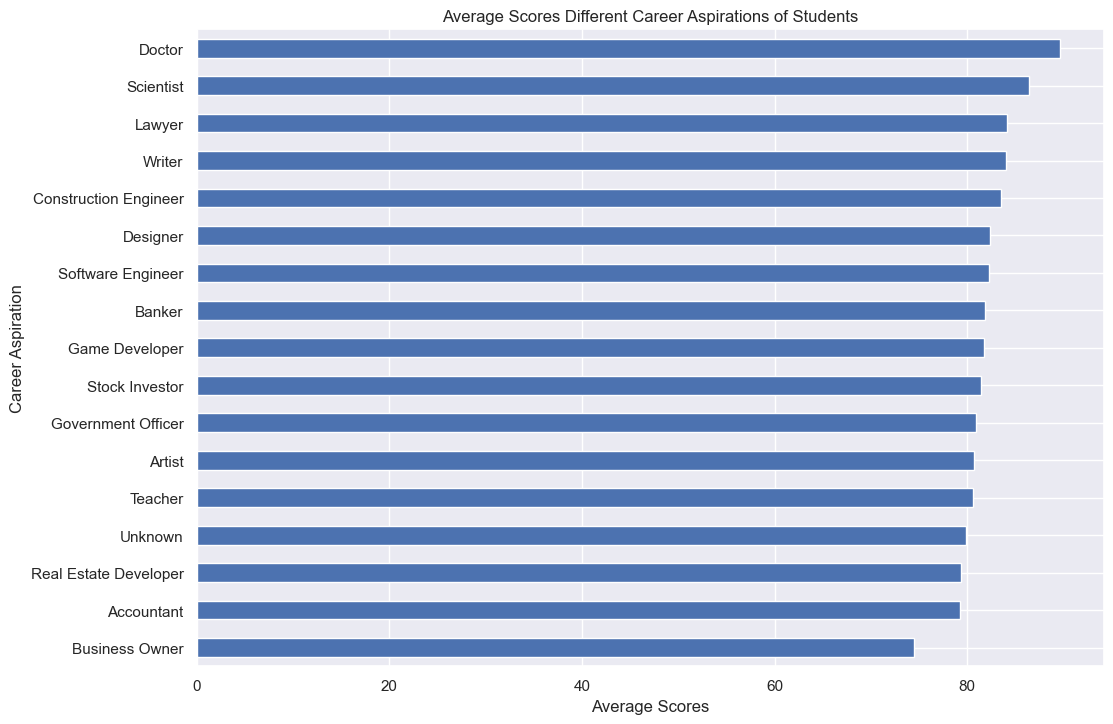

In [19]:
avg_career_score = df.groupby('career_aspiration')['avg_score'].mean().sort_values() # Calculate the average scores of each career aspiration

avg_career_score.plot(kind='barh')
plt.title('Average Scores Different Career Aspirations of Students')
plt.xlabel('Average Scores')
plt.ylabel('Career Aspiration')

Text(0, 0.5, 'Scores')

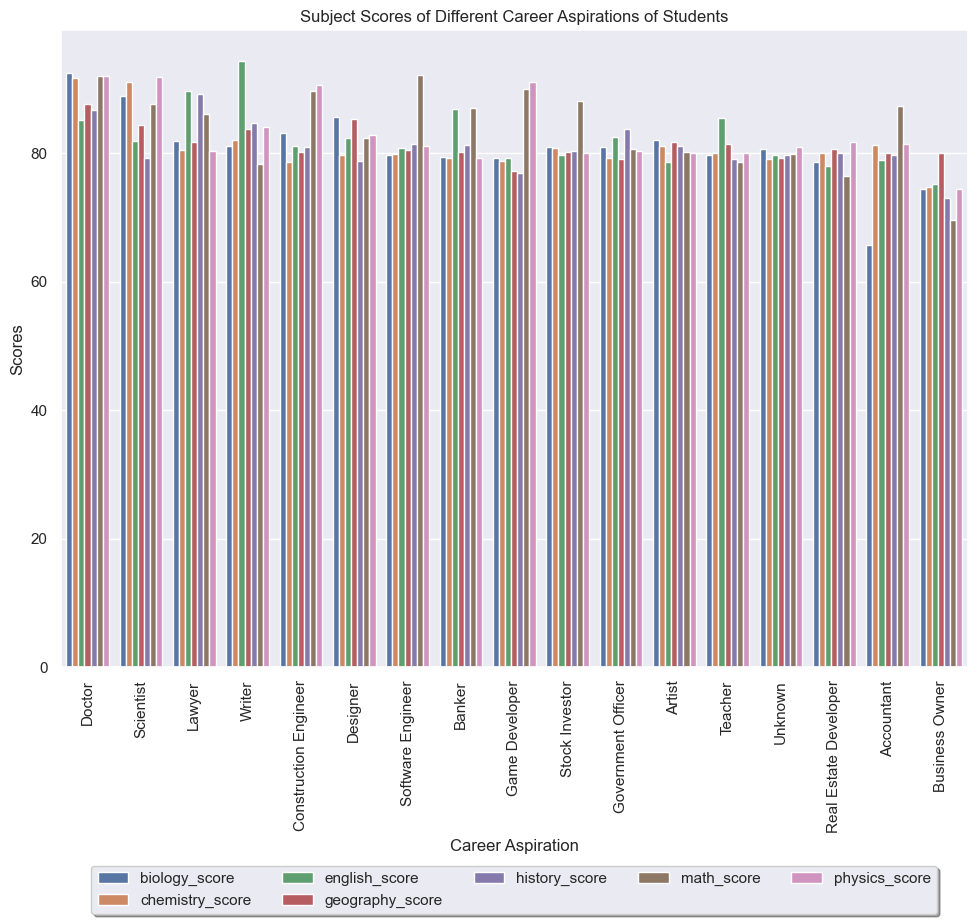

In [20]:
career = pd.melt( # Create a new data frame that holds each career and score for each record
    pd.concat( # Concatenate the careers and subjects
        [df['career_aspiration'],
         df[subjects[:-1]]], # Exclude the average score
         axis=1
        ),
    id_vars='career_aspiration', # Use the career aspiration as a key
    var_name="Subject", # Call the Subject
    value_name="Score" # Call the Score
    )

career_subjects = career.groupby(['career_aspiration','Subject']).mean().reindex( # Group by career and subject
    reversed(avg_career_score.index), # Use the order of the average score for easy comparison on display
    level=0
    )

sns.barplot(
    data=career_subjects,
    x='career_aspiration',
    y='Score',
    hue='Subject' # Use the subject as a legend
    )
plt.xticks(rotation = 90)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3),fancybox=True, shadow=True, ncol=5) # Legend placement
plt.title('Subject Scores of Different Career Aspirations of Students')
plt.xlabel('Career Aspiration')
plt.ylabel('Scores')

Here are the deductions from the charts above
1. Students aspiring to be among high profile careers eg. Doctors, Scientist, Lawyers etc, have higher average scores with Business Owner aspirants having the lowest average scores
2. Doctor Aspirants have the highest biology and chemistry scores on average
3. Writer Aspirants have the highest English Scores on average
4. Software Engineer Aspirants have the highest Math Scores on average
5. Lawyer Aspirants have the highest History Scores on average
6. Accountant Aspirant scores in Math and Physics tend to be better on average, proving the earlier theory that these students focus more on calulation related subjects in self study. This, however, does not disprove the other theories
7. Scientist Aspirants have the highest Physics scores on average
8. Teacher Aspirants scores in English tend to be better on average
9. Game Developer Aspirants scores in Math and Physics tend to be better on average

From the above chart and inferences it is clear that Career Aspirations have a big pull on Subject scores. Science related aspirants tend to do better in science subjects and it is the same for the Arts and Commerce. Do aspirations however have an effect on self study hours?

Text(0, 0.5, 'Weekly Self Study Hours')

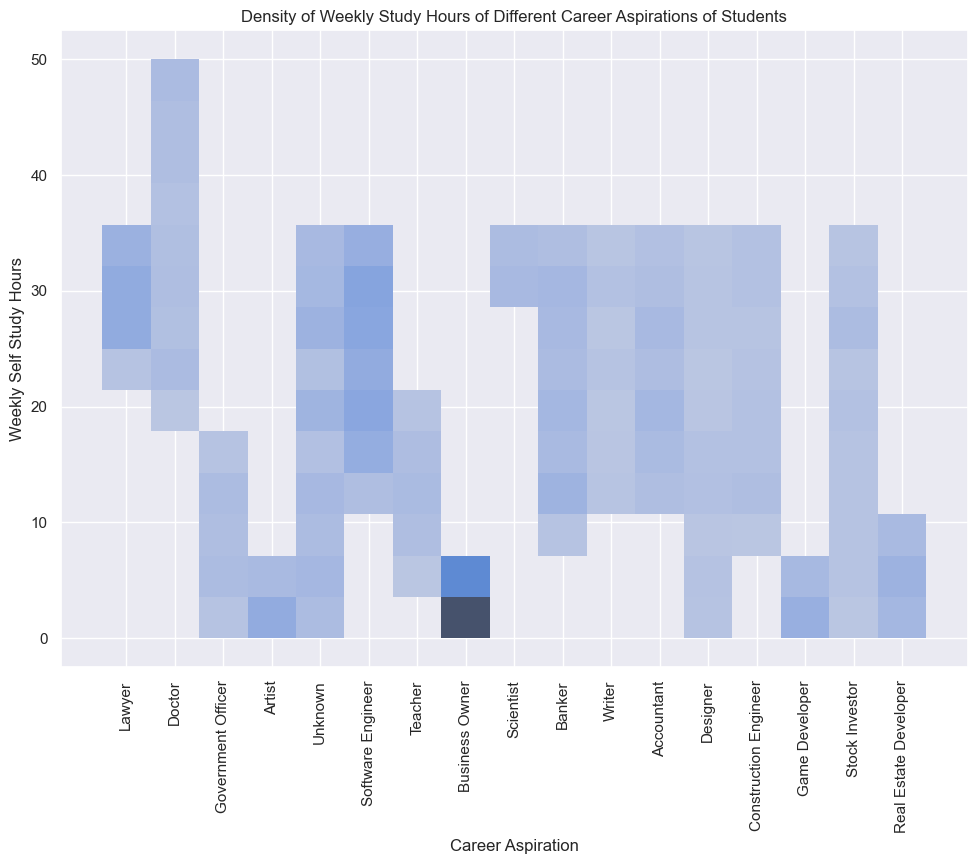

In [21]:
sns.histplot(data=df,x='career_aspiration',y='weekly_self_study_hours') # Display the density of weekly study hours by career aspiration
plt.xticks(rotation=90)
plt.title('Density of Weekly Study Hours of Different Career Aspirations of Students')
plt.xlabel('Career Aspiration')
plt.ylabel('Weekly Self Study Hours')

Text(0, 0.5, 'Average Scores')

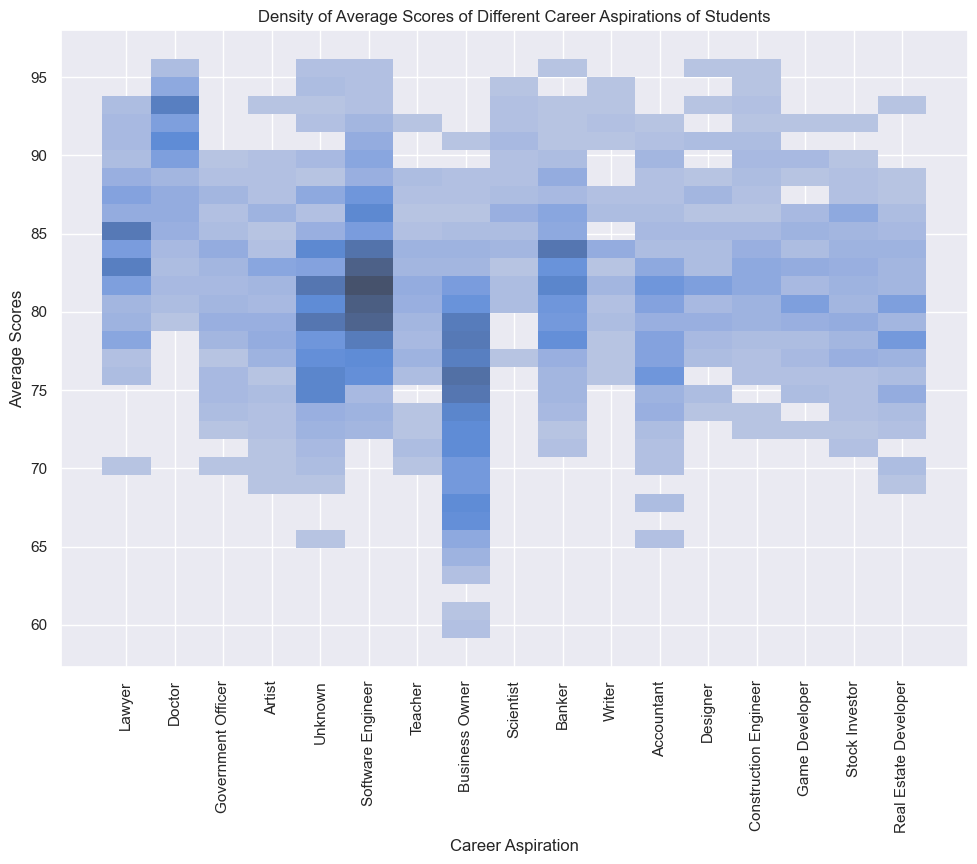

In [22]:
sns.histplot(data=df,x='career_aspiration',y='avg_score')
plt.xticks(rotation=90)
plt.title('Density of Average Scores of Different Career Aspirations of Students')
plt.xlabel('Career Aspiration')
plt.ylabel('Average Scores')

From the Charts above we notice that career aspiration populations which tend to have higher study times have higher scores as well and the same for those with lower study times. We also take note tha students with Business Owner Aspirations have the lowest study time (less than 10 hours), and in turn have the lowest scores. Game Developer Aspirants, despite having low study times (less than 10 Hours) still perform quite average in test

# Findings
1. Positive relationship between Self Study Hours and performace in Tests
2. Negative relationship between number of days absent from school an performace in Tests
3. Students who are regularly absent tend not to study in preparation for Tests and end up with lower scores
4. Career ambitions strongly affect performance in certain subjects, performance all round and tendency for self study
5. Presence of outlier students who acheive high score irrespective of all other factors
6. Students with aspirations in Accounting tend to have lower Biology Scores despite high study times
7. Performance in Math Tests is very dependent on presence in math classes
8. Math Scores have the largest influence on academic success

# Recommendations
1. Specialised surveys for students with aspirations in Accounting to investigate the causes of their low Biology Scores, despite high Study Hours
2. Sensitisation of students with aspirations of owning a Business on the importance of studying and performing well in school along with possible involvement of their parents for parent-teacher meetings
3. Parent-Teacher meetings for students who are chronically absent from class to address their truancy and a suggestion for parents to ensure their students have self study times especially in Math
